# Train Model Workflow

This notebook mirrors `train_model.py`, organized into logical steps.

## 1. Imports

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib

## 2. Load And Prepare Dataset

In [25]:
# Load dataset
df = pd.read_csv('cleaned_dataset.csv')
df = df.sort_values(by='game_date')  # Sort by date

player_cols = ["double_digit_scorers", 'top_points_avg', 'top_points_position', 'top_player_last_5_avg',
               'top_pra_avg', 'one_player_reliance', 'reliance_ranking', 'double_digit_scorers_ranking']

non_int_cols = ['opponent_team_uid_home', 'opponent_team_slug_home', 'opponent_team_short_display_name_home', 'opponent_team_uid_away', 'opponent_team_slug_away', 'opponent_team_short_display_name_away']

df.drop(columns=non_int_cols, inplace=True)

# Drop rank, pct, and unnecessary rate columns
df.drop(columns=[col for col in df.columns if 'rank' in col.lower() and col not in player_cols], inplace=True)
df.drop(columns=[col for col in df.columns if 'pct' in col.lower()], inplace=True)
df.drop(columns=[col for col in df.columns if 'rate' in col.lower() and not any(x in col.lower() for x in ['turnover_rate', 'offensive_rebound_rate', 'free_throw_rate'])], inplace=True)

In [ ]:
print("Pre: Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

df.fillna(0, inplace=True)

print("Post: Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

## 3. Train/Test Split And Shared Config

In [31]:
# Split train/test based on date
split_date = '2023-11-01'
train_df = df[df['game_date'] <= split_date].copy()
test_df = df[df['game_date'] > split_date].copy()

excluded_columns = ['Unnamed: 0', 'game_id', 'game_date', 'home_team', 'home_color', 'away_team', 'away_color', 'target', 'seed_diff']

In [32]:
train_df.tail(10)

,Unnamed: 0,game_id,season_type,game_date,home_team,home_color,target,away_team,away_color,seed_diff,...,non_conf_win_percentage_diff,opponent_recent_win_loss_5_diff,opponent_recent_win_loss_10_diff,opponent_recent_win_loss_15_diff,momentum_5_diff,momentum_10_diff,momentum_15_diff,weighted_momentum_5_diff,weighted_momentum_10_diff,weighted_momentum_15_diff
106570,6211,401522190,3,2023-03-25,Gonzaga,041e42,0,UConn,0c2340,0.0,...,0,-783.749600,-749.932706,-704.722689,20.0,10.0,13.333333,-82672.034112,-122366.401130,-95354.886875
106569,6210,401522193,3,2023-03-25,Kansas State,3c0969,0,Florida Atlantic,00447c,0.0,...,0,1736.278001,1609.531902,1424.842924,-40.0,-30.0,-26.666667,177975.059965,261268.226247,213597.794287
106572,6213,401522196,3,2023-03-26,Texas,c15d26,0,Miami,004325,0.0,...,0,296.420117,387.867631,194.405878,20.0,0.0,-6.666667,641080.090003,488161.584014,427555.480652
106571,6212,401522199,3,2023-03-26,San Diego State,BF2C37,1,Creighton,13299e,0.0,...,0,-1694.515328,-1666.903854,-1579.452309,20.0,20.0,13.333333,106105.166260,101058.583847,83710.842592
106573,6214,401526930,3,2023-03-28,North Texas,ffffff,1,Wisconsin,c4012f,0.0,...,0,-2391.825141,-2308.674139,-2111.566817,0.0,20.0,33.333333,128729.832513,217205.428411,294873.325972
106574,6215,401526927,3,2023-03-28,UAB,054338,1,Utah Valley,004812,0.0,...,0,226.853483,318.326479,399.015348,0.0,10.0,6.666667,416625.827262,494347.184762,467030.712750
106575,6216,401526932,3,2023-03-30,North Texas,ffffff,1,UAB,054338,0.0,...,0,-515.136431,-629.674201,-736.248160,0.0,-10.0,0.000000,-41210.914505,-130732.440424,-63808.173869
106576,6217,401522200,3,2023-04-01,San Diego State,BF2C37,1,Florida Atlantic,00447c,0.0,...,0,909.221846,917.697149,1016.452109,0.0,-10.0,0.000000,-366150.506886,-407058.922454,-329215.637919
106577,6218,401522201,3,2023-04-01,UConn,0c2340,1,Miami,004325,0.0,...,0,233.920117,363.777555,377.008373,0.0,10.0,0.000000,429672.328234,516794.090182,469864.329684
106578,6219,401522202,3,2023-04-03,UConn,0c2340,1,San Diego State,BF2C37,0.0,...,0,572.364114,488.934785,510.051242,0.0,0.0,-6.666667,442763.588646,389874.251113,348381.589890


## 4. Train Winner Prediction Model

In [33]:
# Winner prediction model
tournament_games = train_df[train_df['season_type'] == 3].copy()
train_df_weighted = pd.concat([train_df] + [tournament_games.copy() for _ in range(9)], ignore_index=True)  # 5x weight

X_train = train_df_weighted.drop(columns=excluded_columns)
y_train = train_df_weighted['target'].astype(int)
print(X_train.columns.to_list())

X_test = test_df.drop(columns=excluded_columns)
y_test = test_df['target'].astype(int)

model_winner = LGBMClassifier(objective='binary', metric='logloss', boosting_type='gbdt', verbose=-1,
                              learning_rate=0.03, min_child_samples=20, max_depth=6, num_leaves=255, min_data_in_leaf=5,
                              n_estimators=500)

print("\nTraining winner prediction model...")
model_winner.fit(X_train, y_train)

['season_type', 'points_per_game_diff', 'points_stdev_diff', 'assists_per_game_diff', 'assists_stdev_diff', 'blocks_per_game_diff', 'blocks_stdev_diff', 'defensive_rebounds_per_game_diff', 'defensive_rebounds_stdev_diff', 'field_goals_made_per_game_diff', 'field_goals_made_stdev_diff', 'field_goals_attempted_per_game_diff', 'field_goals_attempted_stdev_diff', 'flagrant_fouls_per_game_diff', 'flagrant_fouls_stdev_diff', 'fouls_per_game_diff', 'fouls_stdev_diff', 'free_throws_made_per_game_diff', 'free_throws_made_stdev_diff', 'free_throws_attempted_per_game_diff', 'free_throws_attempted_stdev_diff', 'offensive_rebounds_per_game_diff', 'offensive_rebounds_stdev_diff', 'steals_per_game_diff', 'steals_stdev_diff', 'team_turnovers_per_game_diff', 'team_turnovers_stdev_diff', 'technical_fouls_per_game_diff', 'technical_fouls_stdev_diff', 'three_point_field_goals_made_per_game_diff', 'three_point_field_goals_made_stdev_diff', 'three_point_field_goals_attempted_per_game_diff', 'three_point_fie

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,6
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 5. Train Upset Prediction Model

In [34]:
# Upset prediction model
tournament_df = train_df[train_df['season_type'] == 3].copy()
upset_games = tournament_df[(tournament_df['seed_diff'] < -4) & (tournament_df['target'] == 0)].copy()
upset_df = pd.concat([tournament_df] + [upset_games.copy() for _ in range(9)], ignore_index=True)  # 5x weight

X_train_upset = upset_df.drop(columns=excluded_columns)
y_train_upset = upset_df['target'].astype(int)

model_upset = LGBMClassifier(objective='binary', metric='logloss', boosting_type='gbdt', verbose=-1,
                             learning_rate=0.05, min_child_samples=20, max_depth=4, num_leaves=127, min_data_in_leaf=5,
                             n_estimators=500, scale_pos_weight=0.4)

print("\nTraining upset prediction model...")
model_upset.fit(X_train_upset, y_train_upset)


Training upset prediction model...


,boosting_type,'gbdt'
,num_leaves,127
,max_depth,4
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 6. Save Models

In [36]:
joblib.dump(model_winner, 'models/lgbm_winner_model.joblib')
joblib.dump(model_upset, 'models/lgbm_upset_model.joblib')

['models/lgbm_upset_model.joblib']

## 7. Define Evaluation Helper

In [37]:
def evaluate_thresholds(model, X_test, y_test, model_name):
    thresholds = np.linspace(0.1, 0.8, 10)  # Test thresholds from 0.1 to 0.8
    metrics = []

    # Create mask for actual 0 values (away team wins)
    actual_zero_mask = (y_test == 0)

    for thresh in thresholds:
        # Get predictions based on threshold
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_thresh = (y_pred_proba > thresh).astype(int)

        # Calculate standard metrics
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)

        # Calculate accuracy for cases where the actual value is 0
        # This shows how well the model identifies games where away team wins
        if np.sum(actual_zero_mask) > 0:
            actual_zero_accuracy = accuracy_score(
                y_test[actual_zero_mask],
                y_pred_thresh[actual_zero_mask]
            )
        else:
            actual_zero_accuracy = 0

        metrics.append([thresh, precision, recall, f1, accuracy, actual_zero_accuracy])

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=["Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Accuracy_Actual_0"]
    )

    # Plot metrics
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy_Actual_0",
                 label="Accuracy When Away Team Wins", marker="o", linestyle="--", color="purple")

    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print count of actual away team wins
    print(f"Number of actual away team wins in test set: {np.sum(actual_zero_mask)}")

    # Find and return the best threshold based on F1 Score
    best_threshold = metrics_df.loc[metrics_df["F1 Score"].idxmax(), "Threshold"]
    return best_threshold

## 8. Evaluate Thresholds

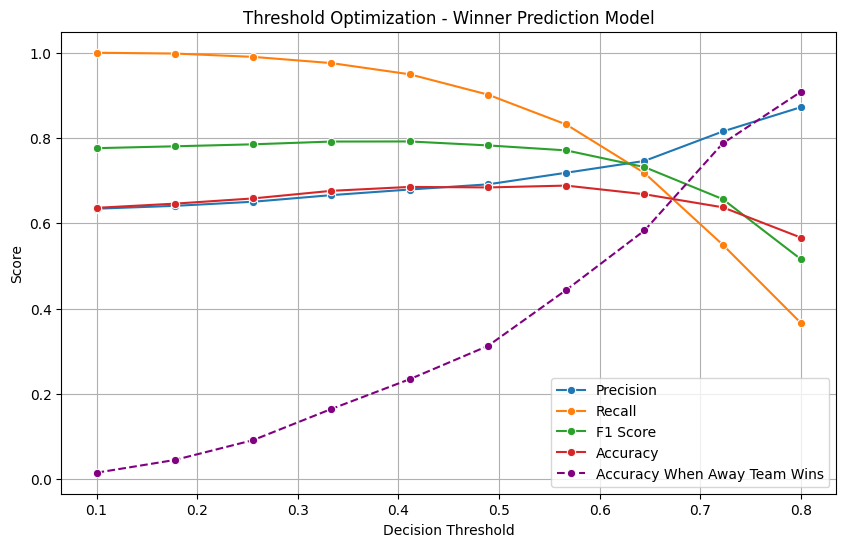

Number of actual away team wins in test set: 602


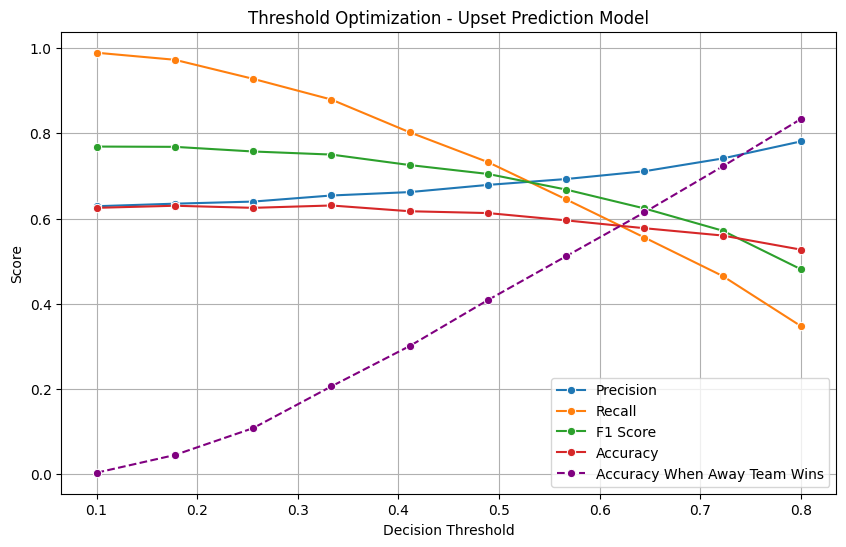

Number of actual away team wins in test set: 602

Optimal Decision Threshold (Winner Model): 0.41
Optimal Decision Threshold (Upset Model): 0.10


In [38]:
best_thresh_winner = evaluate_thresholds(model_winner, X_test, y_test, "Winner Prediction Model")
best_thresh_upset = evaluate_thresholds(model_upset, X_test, y_test, "Upset Prediction Model")

print(f"\nOptimal Decision Threshold (Winner Model): {best_thresh_winner:.2f}")
print(f"Optimal Decision Threshold (Upset Model): {best_thresh_upset:.2f}")

## 9. Define Feature Importance Helper

In [39]:
def plot_feature_importance(model, X_train, model_name):
    feature_importances = model.feature_importances_
    feature_names = X_train.columns

    feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    top_20_features = feat_importance_df.sort_values(by="Importance", ascending=False).head(30)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Top 20 Features - {model_name}")
    plt.show()

## 10. Plot Feature Importances

C:\Users\johns\AppData\Local\Temp\ipykernel_8696\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


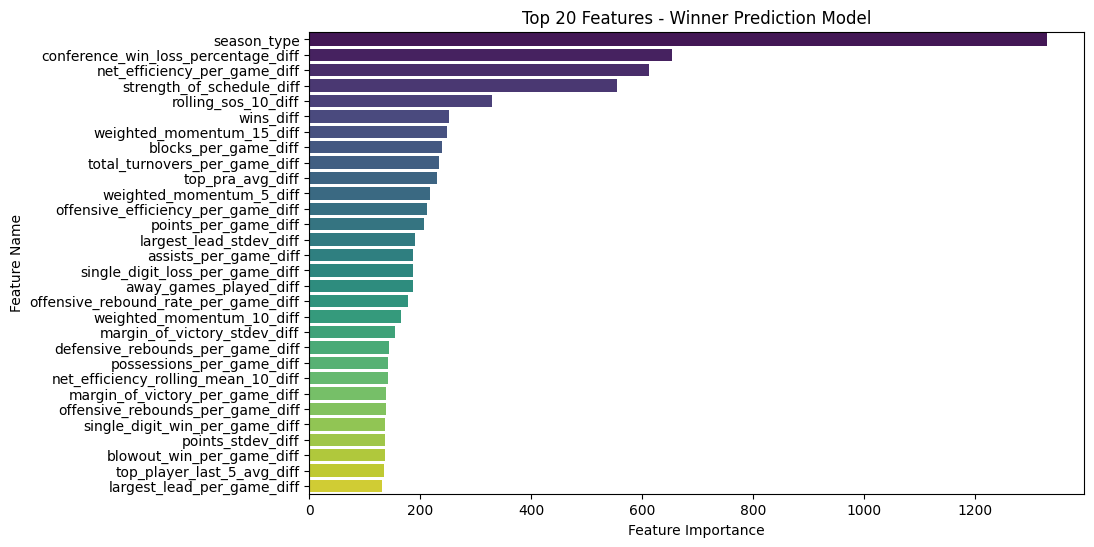

C:\Users\johns\AppData\Local\Temp\ipykernel_8696\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


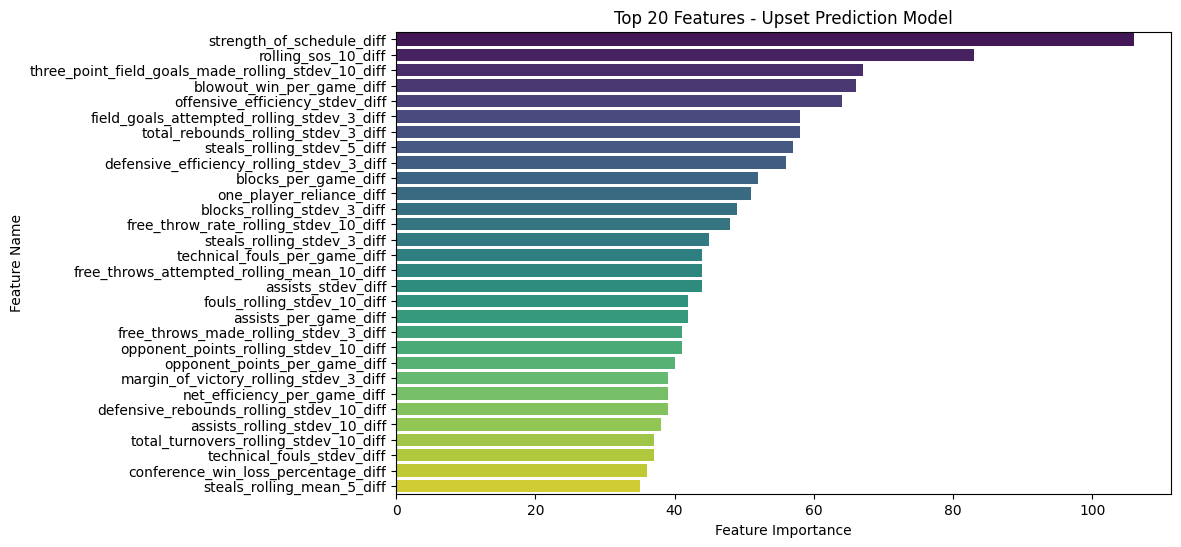

In [40]:
plot_feature_importance(model_winner, X_train, "Winner Prediction Model")
plot_feature_importance(model_upset, X_train_upset, "Upset Prediction Model")